# Perceptron Trick (Single Layer Neural Network)

### Implementing Logistic Regression using a single perceptron and comparing it with scikit learn's implementation on a toy dataset

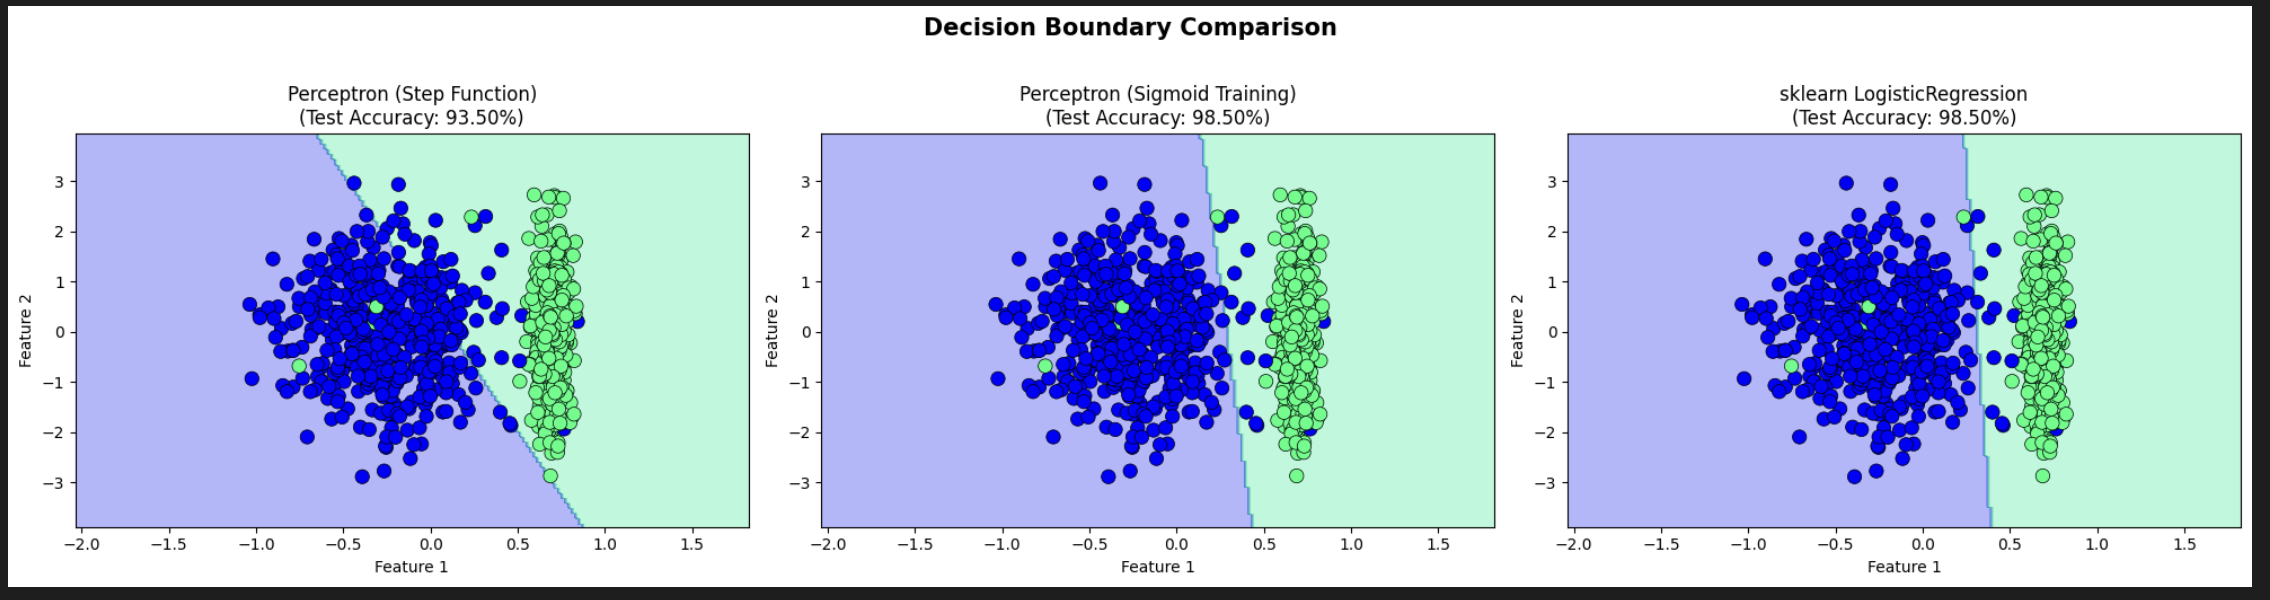

In [518]:
import pandas as pd 
import numpy as np 
from sklearn.datasets import make_classification 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LogisticRegression

we are making a toy dataset using make_classification function

In [519]:
X, y = make_classification(n_samples=1000, n_features=2, n_informative=1,n_redundant=0,n_classes=2, n_clusters_per_class=1, random_state=42,hypercube=False,class_sep=1)

In [520]:
X.shape

(1000, 2)

In [521]:
y.shape

(1000,)

Our data is linearly seperable

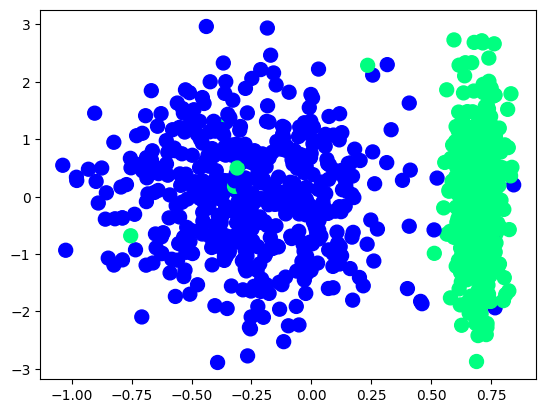

In [522]:
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [523]:
X.shape

(1000, 2)

## Perceptron Trick

##  What is a Perceptron?
 
- A Perceptron is the simplest form of an artificial neural network
- It is a single-layer binary classifier that mimics a biological neuron. 
- It takes multiple inputs, multiplies each by a corresponding weight, sums them up (with a bias), and passes the result through an activation function to produce a binary output.


Given input vector X = [x1, x2, ..., xn] and weights W = [w0, w1, ..., wn] (where w0 is the bias):


z = w0 + w1*x1 + w2*x2 + ... + wn*xn       
z = W^T * X  (with bias absorbed via prepending 1 to X)          
y_hat = step(z)


In [524]:
def step(z):
    return 1 if z>0 else 0

First we will use Step function

In [525]:
class perceptron():
    def __init__(self,learning_rate=0.1,epochs=200):
        self.learning_rate=learning_rate
        self.epochs=epochs
        self.weights = None
    def fit(self,X,y):
        X=np.insert(X,0,1,axis=1)
        self.weights= np.ones(X.shape[1])
        for i in range(self.epochs):
            j=np.random.randint(0,X.shape[0])
            y_hat=step(np.dot(X[j],self.weights))
            self.weights=self.weights + self.learning_rate* (y_train[j]-y_hat)*X[j]
        return self.weights[0] , self.weights[1:]
    def predict(self, X):
        X = np.insert(X, 0, 1, axis=1)
        return np.array([step(np.dot(x, self.weights)) for x in X])

## Intuition
- the wronly classified points are kind of pulling the line towards them to be in right area

Now lets implement the sigmoid function too!

In [526]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [ ]:
class perceptron_sigmoid():
    def __init__(self,learning_rate=0.1,epochs=200):
        self.learning_rate=learning_rate
        self.epochs=epochs
        self.weights = None
    def fit(self,X,y):
        X=np.insert(X,0,1,axis=1)
        self.weights= np.ones(X.shape[1])
        for i in range(self.epochs):
            j=np.random.randint(0,X.shape[0])

            # Instead of step use sigmoid function
            y_hat=sigmoid(np.dot(X[j],self.weights))
            self.weights=self.weights + self.learning_rate* (y_train[j]-y_hat)*X[j]
        return self.weights[0] , self.weights[1:]
    def predict(self, X):
        X = np.insert(X, 0, 1, axis=1)
        return np.array([step(np.dot(x, self.weights)) for x in X])

In [528]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = perceptron(learning_rate=0.1, epochs=1000)

sigper= perceptron_sigmoid(learning_rate=0.1, epochs=1000)

bias_sigmoid, weights_sigmoid= sigper.fit(X_train,y_train)

bias, weights = clf.fit(X_train, y_train)
print(f"Bias (w0)  : {bias:.4f}")
print(f"Weights    : {weights}")

bia_sigmoid, weights_sigmoid = clf.fit(X_train, y_train)
print(f"Bias for sigmoid(w0)  : {bias_sigmoid:.4f}")
print(f"Weights  for sigmoid  : {weights_sigmoid}")

Bias (w0)  : -0.2000
Weights    : [ 0.78123827 -0.00662137]
Bias for sigmoid(w0)  : -1.6912
Weights  for sigmoid  : [0.87344472 0.17079062]


In [529]:
from sklearn.metrics import accuracy_score
# Perceptron using step function 
y_pred_custom = clf.predict(X_test)
acc_custom = accuracy_score(y_test, y_pred_custom)

# Perceptron using Sigmoid function
y_pred_sigmoid= sigper.predict(X_test)
acc_sigmoid= accuracy_score(y_test,y_pred_sigmoid)

# sklearn LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_sklearn = lr.predict(X_test)
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)
print(f"Custom Perceptron Accuracy : {acc_custom * 100:.2f}%")
print(f"sigmoid Perceptron Accuracy : {acc_sigmoid * 100:.2f}%")
print(f"sklearn LogisticRegression : {acc_sklearn * 100:.2f}%")

Custom Perceptron Accuracy : 93.50%
sigmoid Perceptron Accuracy : 98.50%
sklearn LogisticRegression : 98.50%


## Convergence Theory
 
### Perceptron Convergence Theorem (Novikoff, 1962)
If a dataset is linearly separable, the perceptron algorithm is guaranteed to converge to a solution that correctly classifies all training examples in a finite number of steps.

### Perceptron Cycling Theorem
If the data is **not** linearly separable, the perceptron will never converge. It will cycle through the same set of weights indefinitely. This is why a max epoch limit is always used in practice.
 
 
> our implemented class also gives 100 percentage accuracy then whats the difference?             
> Now comparing both the lines diagramtically

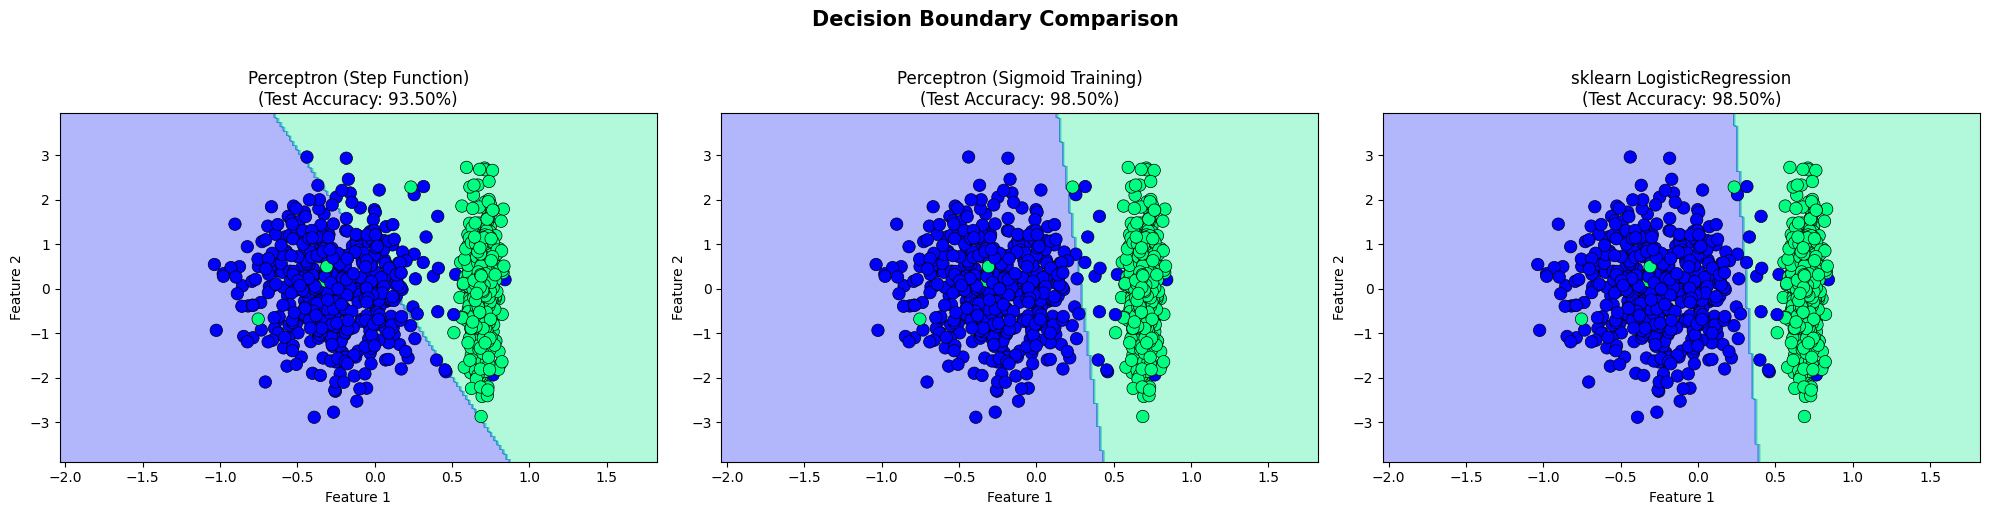

In [531]:
def plot_decision_boundary(clf_custom, clf_sigmoid, clf_sklearn, X, y):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z_custom  = clf_custom.predict(grid).reshape(xx.shape)
    Z_sigmoid = clf_sigmoid.predict(grid).reshape(xx.shape)
    Z_sklearn = clf_sklearn.predict(grid).reshape(xx.shape)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    configs = [
        (axes[0], Z_custom,  clf_custom,  'Perceptron (Step Function)'),
        (axes[1], Z_sigmoid, clf_sigmoid, 'Perceptron (Sigmoid Training)'),
        (axes[2], Z_sklearn, clf_sklearn, 'sklearn LogisticRegression'),
    ]

    for ax, Z, clf, title in configs:
        ax.contourf(xx, yy, Z, alpha=0.3, cmap='winter')
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap='winter',
                   s=80, edgecolors='k', linewidths=0.5)
        acc = accuracy_score(y_test, clf.predict(X_test)) * 100
        ax.set_title(f'{title}\n(Test Accuracy: {acc:.2f}%)', fontsize=12)
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')

    plt.suptitle('Decision Boundary Comparison',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_decision_boundary(clf, sigper, lr, X, y)

> Our model was nearly 100 percent accurate due to the perceptron convergence theorem however it will not generlize well on new data as it line does not guarantee maximum seperation


##  Practical Considerations
 
- **Feature scaling**: the perceptron is sensitive to the scale of features because weight updates are proportional to `x_j`. Always normalize or standardize inputs.
- **Learning rate**: too large and updates overshoot; too small and convergence is slow.
- **Initialization**: initializing weights to zero vs ones vs random all work, but behavior during early epochs differs.
- **Non-separable data**: the perceptron will not converge. Use logistic regression, SVM, or MLP instead. In the perceptron, limit epochs and consider the pocket variant.
- **No probabilistic interpretation**: the perceptron gives no confidence scores. If you need probabilities, use logistic regression.
